# This analysis is done using Julius AI

## Key Features of the Dataset:
Comprehensive Sleep Metrics: Explore sleep duration, quality, and factors influencing sleep patterns.
Lifestyle Factors: Analyze physical activity levels, stress levels, and BMI categories.
Cardiovascular Health: Examine blood pressure and heart rate measurements.
Sleep Disorder Analysis: Identify the occurrence of sleep disorders such as Insomnia and Sleep Apnea.

################################

## Dataset Columns:

Person ID: An identifier for each individual.

Gender: The gender of the person (Male/Female).

Age: The age of the person in years.

Occupation: The occupation or profession of the person.

Sleep Duration (hours): The number of hours the person sleeps per day.

Quality of Sleep (scale: 1-10): A subjective rating of the quality of sleep, ranging from 1 to 10.

Physical Activity Level (minutes/day): The number of minutes the person engages in physical activity daily.

Stress Level (scale: 1-10): A subjective rating of the stress level experienced by the person, ranging from 1 to 10.

BMI Category: The BMI category of the person (e.g., Underweight, Normal, Overweight).

Blood Pressure (systolic/diastolic): The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure.

Heart Rate (bpm): The resting heart rate of the person in beats per minute.

Daily Steps: The number of steps the person takes per day.

Sleep Disorder: The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea).

Details about Sleep Disorder Column:
- None: The individual does not exhibit any specific sleep disorder.
- Insomnia: The individual experiences difficulty falling asleep or staying asleep, leading to inadequate or poor-quality sleep.
- Sleep Apnea: The individual suffers from pauses in breathing during sleep, resulting in disrupted sleep patterns and potential health risks.

In [39]:
# Load dataset and analyze Age vs Quality of Sleep by Occupation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV
file_path = 'data_Sleep_health_and_lifestyle_dataset.csv'
df = pd.read_csv(file_path, encoding='ascii')
print(df.head(10))

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   
5          6   Male   28     Software Engineer             5.9   
6          7   Male   29               Teacher             6.3   
7          8   Male   29                Doctor             7.8   
8          9   Male   29                Doctor             7.8   
9         10   Male   29                Doctor             7.8   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60    

In [40]:
print(df.shape) # rows,col

(374, 13)


In [41]:
# lets look at all the columns
print(df.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')


In [42]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None


In [43]:
print(df.describe())

        Person ID         Age  Sleep Duration  Quality of Sleep  \
count  374.000000  374.000000      374.000000        374.000000   
mean   187.500000   42.184492        7.132086          7.312834   
std    108.108742    8.673133        0.795657          1.196956   
min      1.000000   27.000000        5.800000          4.000000   
25%     94.250000   35.250000        6.400000          6.000000   
50%    187.500000   43.000000        7.200000          7.000000   
75%    280.750000   50.000000        7.800000          8.000000   
max    374.000000   59.000000        8.500000          9.000000   

       Physical Activity Level  Stress Level  Heart Rate   Daily Steps  
count               374.000000    374.000000  374.000000    374.000000  
mean                 59.171123      5.385027   70.165775   6816.844920  
std                  20.830804      1.774526    4.135676   1617.915679  
min                  30.000000      3.000000   65.000000   3000.000000  
25%                  45.000000 

In [44]:
# Checking for Null Values
print(df.isnull().sum())
# The absence of values for column Sleep disorder means that the person does not have disorder

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [45]:
# Get unique value counts for each column
unique_counts = df.nunique()
print(unique_counts)

Person ID                  374
Gender                       2
Age                         31
Occupation                  11
Sleep Duration              27
Quality of Sleep             6
Physical Activity Level     16
Stress Level                 6
BMI Category                 4
Blood Pressure              25
Heart Rate                  19
Daily Steps                 20
Sleep Disorder               2
dtype: int64


In [46]:
# Lets see what each column holds
columns = ['Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder']
for c in columns:
    print(f"{c}: {df[c].unique()}")
    # print(df[c].value_counts())
    print("#################")

Gender: ['Male' 'Female']
#################
Age: [27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 48 49 50 51 52
 53 54 55 56 57 58 59]
#################
Occupation: ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
#################
Sleep Duration: [6.1 6.2 5.9 6.3 7.8 6.  6.5 7.6 7.7 7.9 6.4 7.5 7.2 5.8 6.7 7.3 7.4 7.1
 6.6 6.9 8.  6.8 8.1 8.3 8.5 8.4 8.2]
#################
Quality of Sleep: [6 4 7 5 8 9]
#################
Physical Activity Level: [42 60 30 40 75 35 45 50 32 70 80 55 90 47 65 85]
#################
Stress Level: [6 8 7 4 3 5]
#################
BMI Category: ['Overweight' 'Normal' 'Obese' 'Normal Weight']
#################
Blood Pressure: ['126/83' '125/80' '140/90' '120/80' '132/87' '130/86' '117/76' '118/76'
 '128/85' '131/86' '128/84' '115/75' '135/88' '129/84' '130/85' '115/78'
 '119/77' '121/79' '125/82' '135/90' '122/80' '142/92' '140/95' '139/91'
 '118/75']
#####

In [47]:
# Now lets find count of each values for above columns:
columns = ['Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder']
for c in columns:
    print(df[c].value_counts())
    print("#################")


Gender
Male      189
Female    185
Name: count, dtype: int64
#################
Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
45    14
33    13
30    13
29    13
35    12
36    12
41    12
49    11
57     9
52     9
42     9
51     8
54     7
58     6
28     5
40     4
48     3
55     2
56     2
34     2
27     1
Name: count, dtype: int64
#################
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64
#################
Sleep Duration
7.2    36
6.0    31
7.8    28
6.5    26
6.1    25
7.7    24
6.6    20
7.1    19
8.1    15
7.3    14
8.4    14
6.3    13
8.5    13
8.0    13
6.2    12
8.2    11
7.6    10
6.4     9
7.9     7
7.4     5
6.7     5
7.5     5
6.8    

Gender
Male      189
Female    185
Name: count, dtype: int64
['Male', 'Female']


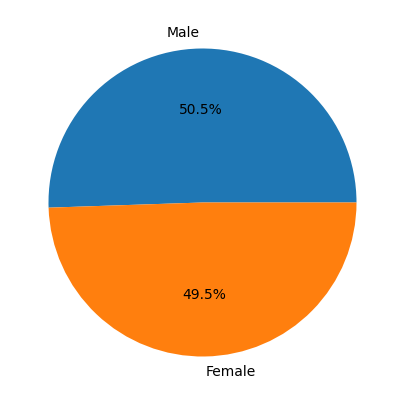

Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
45    14
33    13
30    13
29    13
35    12
36    12
41    12
49    11
57     9
52     9
42     9
51     8
54     7
58     6
28     5
40     4
48     3
55     2
56     2
34     2
27     1
Name: count, dtype: int64
[43, 44, 37, 38, 50, 31, 32, 53, 59, 39, 45, 33, 30, 29, 35, 36, 41, 49, 57, 52, 42, 51, 54, 58, 28, 40, 48, 55, 56, 34, 27]


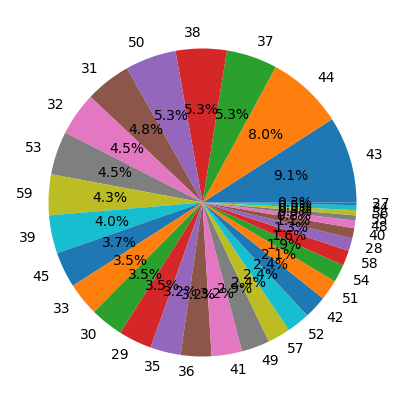

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64
['Nurse', 'Doctor', 'Engineer', 'Lawyer', 'Teacher', 'Accountant', 'Salesperson', 'Software Engineer', 'Scientist', 'Sales Representative', 'Manager']


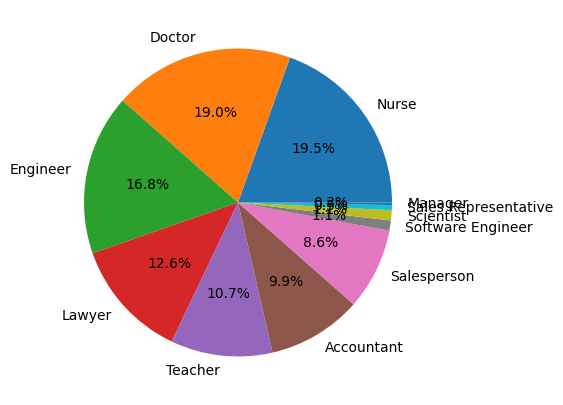

Sleep Duration
7.2    36
6.0    31
7.8    28
6.5    26
6.1    25
7.7    24
6.6    20
7.1    19
8.1    15
7.3    14
8.4    14
6.3    13
8.5    13
8.0    13
6.2    12
8.2    11
7.6    10
6.4     9
7.9     7
7.4     5
6.7     5
7.5     5
6.8     5
8.3     5
5.9     4
6.9     3
5.8     2
Name: count, dtype: int64
[7.2, 6.0, 7.8, 6.5, 6.1, 7.7, 6.6, 7.1, 8.1, 7.3, 8.4, 6.3, 8.5, 8.0, 6.2, 8.2, 7.6, 6.4, 7.9, 7.4, 6.7, 7.5, 6.8, 8.3, 5.9, 6.9, 5.8]


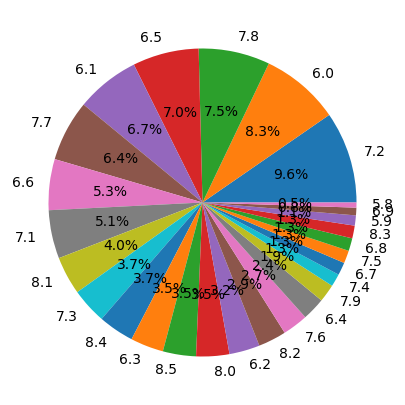

Quality of Sleep
8    109
6    105
7     77
9     71
5      7
4      5
Name: count, dtype: int64
[8, 6, 7, 9, 5, 4]


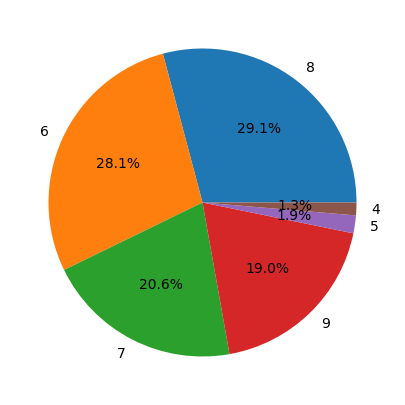

Physical Activity Level
60    70
30    68
45    68
75    67
90    67
40     6
55     6
35     4
50     4
70     3
42     2
32     2
80     2
65     2
85     2
47     1
Name: count, dtype: int64
[60, 30, 45, 75, 90, 40, 55, 35, 50, 70, 42, 32, 80, 65, 85, 47]


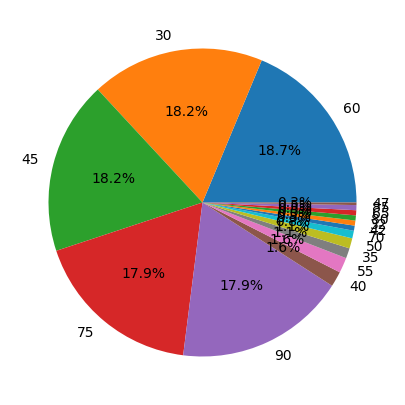

Stress Level
3    71
8    70
4    70
5    67
7    50
6    46
Name: count, dtype: int64
[3, 8, 4, 5, 7, 6]


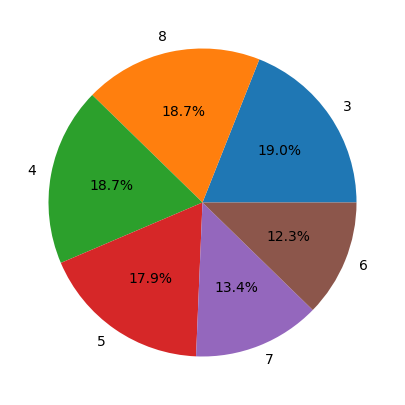

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64
['Normal', 'Overweight', 'Normal Weight', 'Obese']


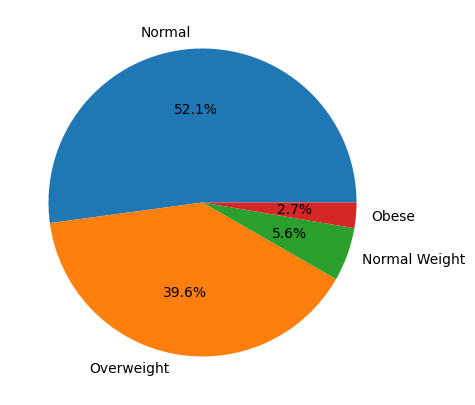

Blood Pressure
130/85    99
140/95    65
125/80    65
120/80    45
115/75    32
135/90    27
140/90     4
125/82     4
132/87     3
128/85     3
126/83     2
115/78     2
139/91     2
142/92     2
119/77     2
135/88     2
129/84     2
128/84     2
131/86     2
117/76     2
130/86     2
118/75     2
121/79     1
122/80     1
118/76     1
Name: count, dtype: int64
['130/85', '140/95', '125/80', '120/80', '115/75', '135/90', '140/90', '125/82', '132/87', '128/85', '126/83', '115/78', '139/91', '142/92', '119/77', '135/88', '129/84', '128/84', '131/86', '117/76', '130/86', '118/75', '121/79', '122/80', '118/76']


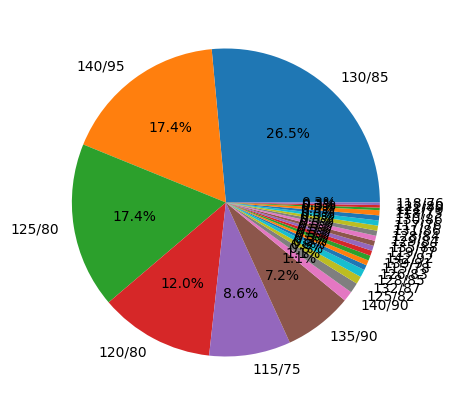

Heart Rate
68    94
70    76
72    69
65    67
75    36
78     5
85     3
80     3
84     2
83     2
73     2
67     2
74     2
77     2
81     2
76     2
69     2
86     2
82     1
Name: count, dtype: int64
[68, 70, 72, 65, 75, 78, 85, 80, 84, 83, 73, 67, 74, 77, 81, 76, 69, 86, 82]


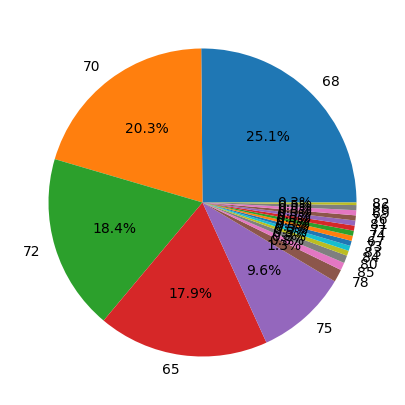

Daily Steps
8000     101
6000      68
5000      68
7000      66
10000     36
5500       4
3000       3
3500       3
4000       3
6800       3
4800       2
7300       2
7500       2
4200       2
3300       2
5600       2
5200       2
4100       2
3700       2
6200       1
Name: count, dtype: int64
[8000, 6000, 5000, 7000, 10000, 5500, 3000, 3500, 4000, 6800, 4800, 7300, 7500, 4200, 3300, 5600, 5200, 4100, 3700, 6200]


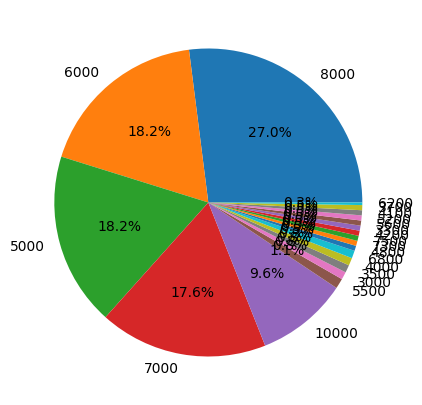

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64
['Sleep Apnea', 'Insomnia']


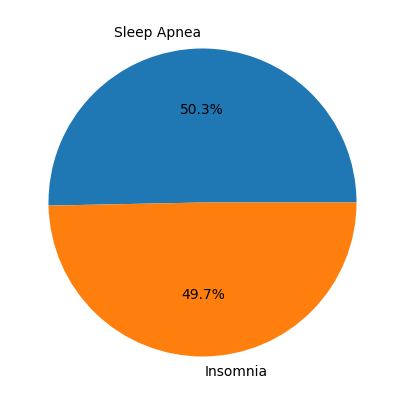

In [48]:
# Lets visualize above value counts with pie plot
#'autopct' displays the percentage upto the 1 decimal
#'radiius' sets the radius of pie plot
# c = 'Gender'
for c in columns:
    plt.figure(figsize = (10, 5))
    data = df[c].value_counts()
    labels = df[c].value_counts().index.tolist() # IMPORTANT: the labels should match with the numbers in data
    print(data)
    print(labels)
    
    plt.pie(data, autopct="%.1f%%", radius=1, labels=labels)
    
    plt.show()

In [49]:
# Are there any outliers ? univariate
df = pd.read_csv(file_path, encoding='ascii')

# Select numeric columns automatically
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Convert any that should be numeric
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

outlier_summary = []
for col in num_cols:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    
    outlier_summary.append({
        'Variable': col,
        'Outlier Count': outliers.shape[0],
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Values': outliers.tolist()
    })

outlier_df = pd.DataFrame(outlier_summary)

# Print the summary with actual outlier values
pd.set_option('display.max_colwidth', None)  # Optional: to avoid truncation
print(outlier_df)


                  Variable  Outlier Count  Lower Bound  Upper Bound  \
0                Person ID              0     -185.500      560.500   
1                      Age              0       13.125       72.125   
2           Sleep Duration              0        4.300        9.900   
3         Quality of Sleep              0        3.000       11.000   
4  Physical Activity Level              0        0.000      120.000   
5             Stress Level              0       -0.500       11.500   
6               Heart Rate             15       62.000       78.000   
7              Daily Steps              0     2000.000    11600.000   

                                                 Outlier Values  
0                                                            []  
1                                                            []  
2                                                            []  
3                                                            []  
4                             

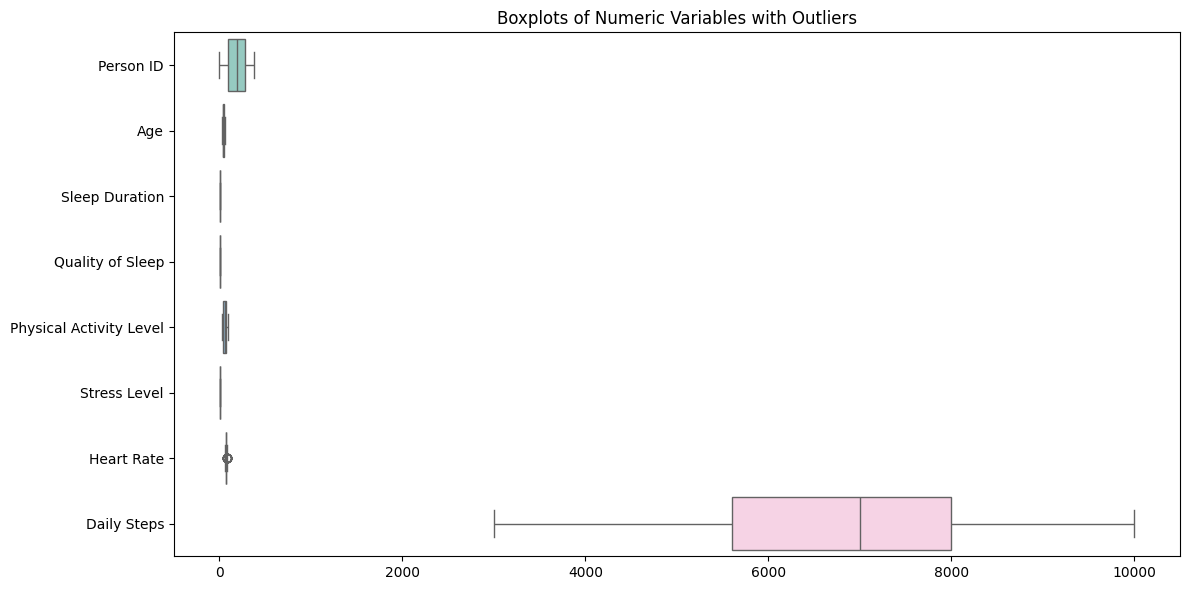

In [50]:
# Lets see if we can spot these outliers in boxplots
# Plot boxplots for each numeric variable
plt.figure(figsize=(12,6))

a = sns.boxplot(data=df[num_cols], orient='h', palette='Set3')
plt.title('Boxplots of Numeric Variables with Outliers')
plt.tight_layout()
plt.show()

# obs: I am not liking the box plot....all squished together. This is because 
# the data range is different for different columns. So I plot them seperately

I am not liking the box plot....all squished together. This is because the data range is different for different columns. So I plot them seperately

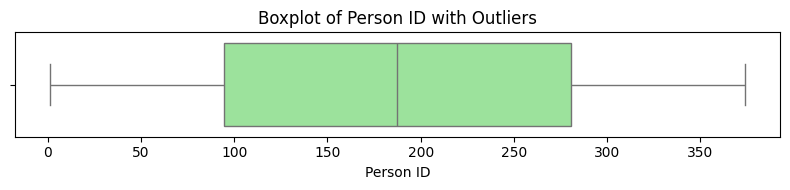

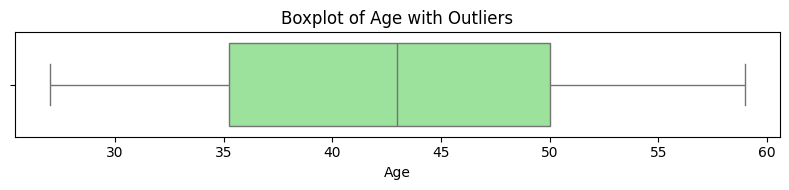

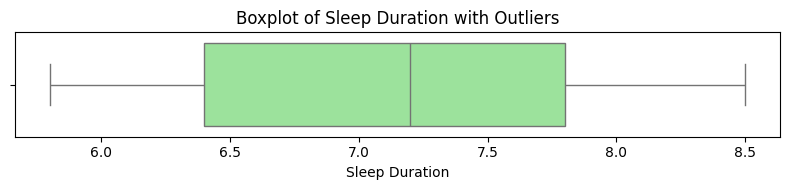

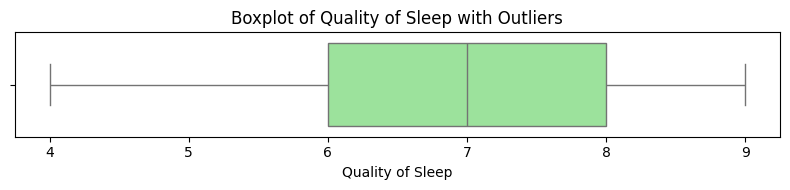

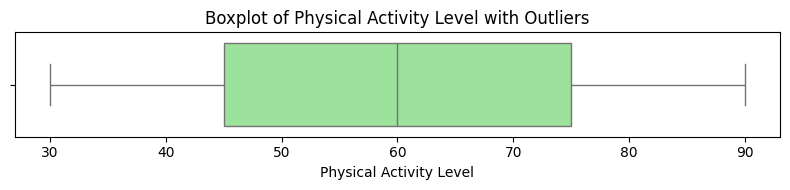

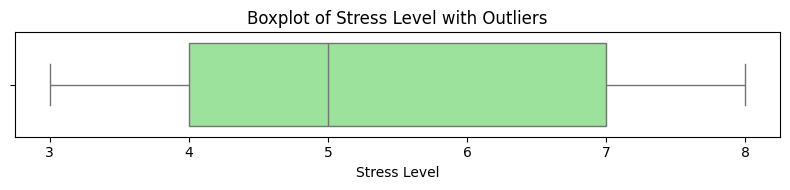

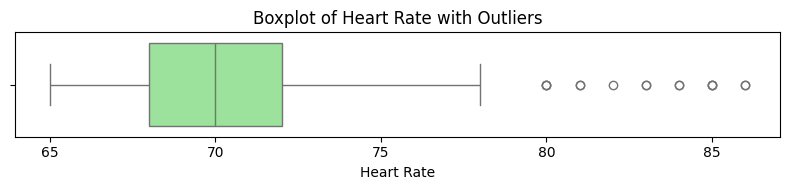

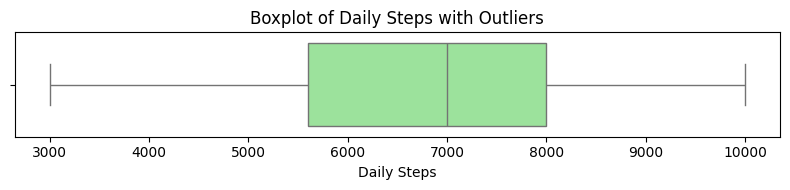

In [51]:
# I am not liking the box plot....all squished together. This is because the data range is different
# for different columns. So I plot them seperately

for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col], orient='h', color='lightgreen')  # Use a single color
    plt.title(f'Boxplot of {col} with Outliers')
    plt.tight_layout()
    plt.show()

# obse: Heart rate actually has 15 outliers, but due to overlapping values box plot is showing only 7.

# observation
The IQR method flagged outliers only in Heart Rate: 15 records lie outside the 
62 and 78 bpm band.
All other numeric fields fall entirely within their IQR fences, so no extreme low-sleep or ultra-high-stress cases under this rule.

count    374.000000
mean       7.312834
std        1.196956
min        4.000000
25%        6.000000
50%        7.000000
75%        8.000000
max        9.000000
Name: Quality of Sleep, dtype: float64
Skewness: -0.20661469385504258


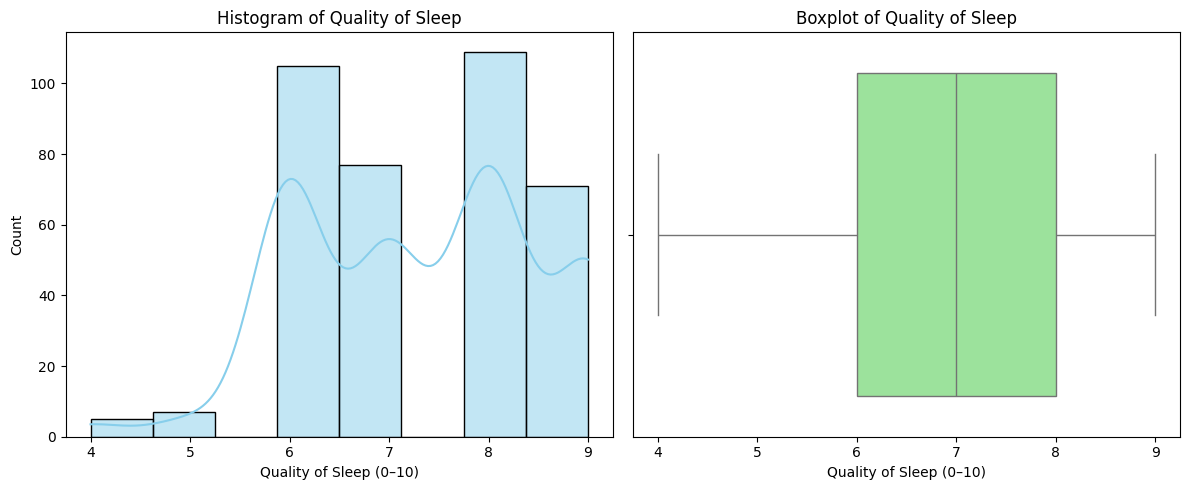

In [52]:
# What is the distribution (histogram/boxplot) of Quality of Sleep? Is it skewed or close to normal? Univariate

from scipy.stats import skew

# Load dataset
df = pd.read_csv(file_path, encoding='ascii')

# Ensure numeric
df['Quality of Sleep'] = pd.to_numeric(df['Quality of Sleep'], errors='coerce')

# Descriptive statistics
qs_desc = df['Quality of Sleep'].describe()
qs_skew = skew(df['Quality of Sleep'].dropna())

print(qs_desc)
print('Skewness:', qs_skew)

# Plot histogram and boxplot side by side
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Quality of Sleep'], bins=8, kde=True, color='skyblue', edgecolor='black')
plt.title('Histogram of Quality of Sleep')
plt.xlabel('Quality of Sleep (0–10)')

plt.subplot(1,2,2)
sns.boxplot(x=df['Quality of Sleep'], color='lightgreen')
plt.title('Boxplot of Quality of Sleep')
plt.xlabel('Quality of Sleep (0–10)')

plt.tight_layout()
plt.show()

# observation
The table shows the descriptive snapshot:

- Center – median = 7 and mean approx. 7.31 sit almost on top of each other.
- Spread – an IQR from 6 to 8 and a modest SD approx 1.20 indicate most scores bunch tightly around the centre.
- Range – values span 4 – 9; the survey never recorded 0–3 or the perfect 10.

### Skewness statistic

Skewness= -0.20661469385504258

A skew of −0.21 is small (rule-of-thumb: |skew|<0.5 ⇒ roughly symmetric).

What the plots confirm ?
- Histogram: the curve is bell-like, peaking at 7 with gentle shoulders—no long tail left or right.
- KDE overlay almost mirrors a normal curve, although the right edge is truncated at 9 so the tail there is - clipped.
- Box-plot: whiskers are balanced, and there are no fliers.

#### Verdict:
Quality-of-Sleep scores are close to normally distributed, slightly left-skewed because the top end is capped. For modelling, treating this variable as approximately normal is reasonable, though remember it is bounded 0–10.

    BMI Category  Count
0         Normal    195
1     Overweight    148
2  Normal Weight     21
3          Obese     10


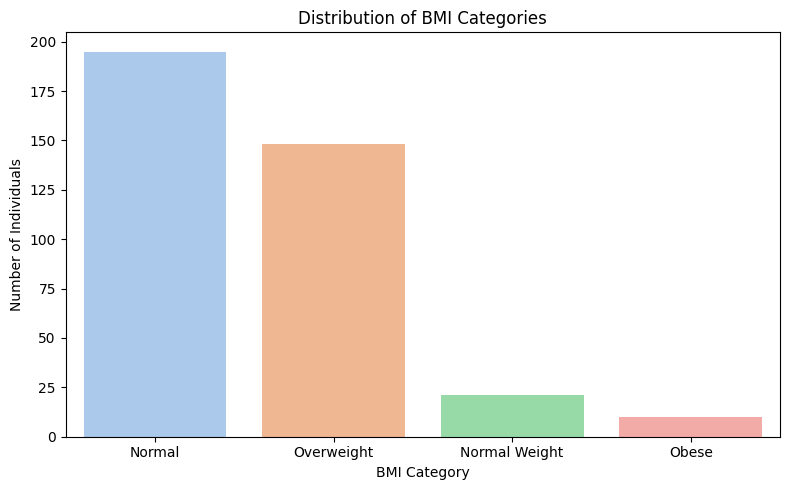

In [53]:
# How are BMI categories split across the sample? univariate

df = pd.read_csv(file_path, encoding='ascii')

# Standardise column name if needed
bmi_col = 'BMI Category'

bmi_counts = df[bmi_col].value_counts().reset_index()
bmi_counts.columns = ['BMI Category', 'Count']

print(bmi_counts)

# Bar plot
plt.figure(figsize=(8,5))
# sns.barplot(data=bmi_counts, x='BMI Category', y='Count', palette='pastel') # From Julia and then below is fixed
sns.barplot(data=bmi_counts, x='BMI Category', y='Count', hue='BMI Category', palette='pastel', legend=False)
plt.title('Distribution of BMI Categories')
plt.ylabel('Number of Individuals')
plt.xlabel('BMI Category')
plt.tight_layout()
plt.show()

# observation
The table gives the raw tally and the bar-plot shows the same proportions visually.

What we see

- “Normal” dominates: a little over half the sample (195 people).
- “Overweight” follows with 148 individuals—about 40 % of the cohort.

Two fringe groups appear:
- “Normal Weight” (likely a redundant or alternative label) with 21 cases.
- “Obese” with only 10 cases (≈ 3 %).

## Interpretation

The dataset skews toward healthier BMI ranges; truly obese participants are rare. That imbalance matters if you plan to model sleep quality against BMI status—predictive power for the Obese class will be weak without resampling or class-weighting.

##### Next logical steps:
- Consolidate “Normal” and “Normal Weight” if they mean the same thing, or clarify the difference.
- Examine whether sleep metrics differ meaningfully between Normal and Overweight groups, since those two make up 90 % of the data.
- If obesity effects are of primary interest, consider augmenting the sample or using synthetic techniques (e.g. SMOTE) before advanced modelling.

C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\hi\AppData\Local\Temp\ipykernel_4332\629486553.py:18: DeprecationWarning: D

   Occupation  Age-Quality Correlation
0  Accountant                -0.805030
1      Doctor                 0.639902
2    Engineer                 0.708933
3      Lawyer                 0.129037
4     Manager                      NaN
#####################################


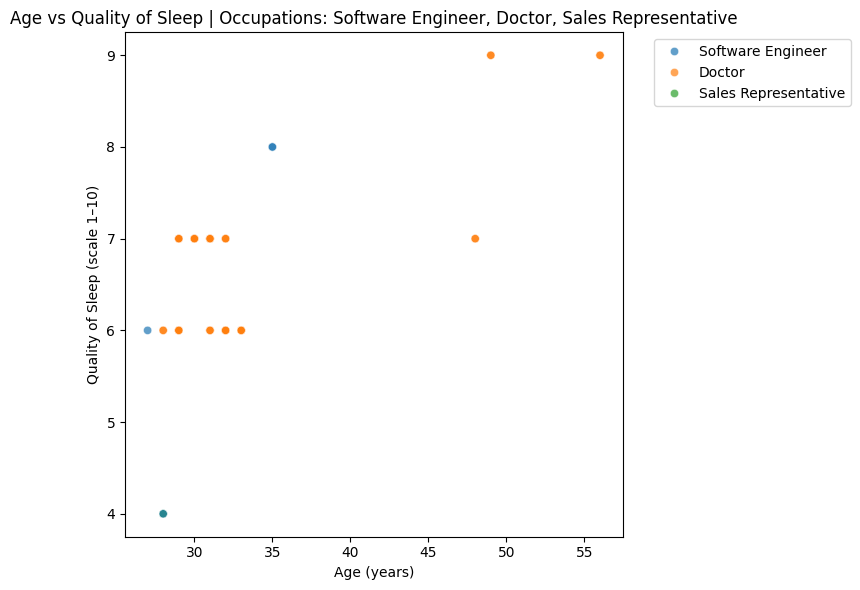

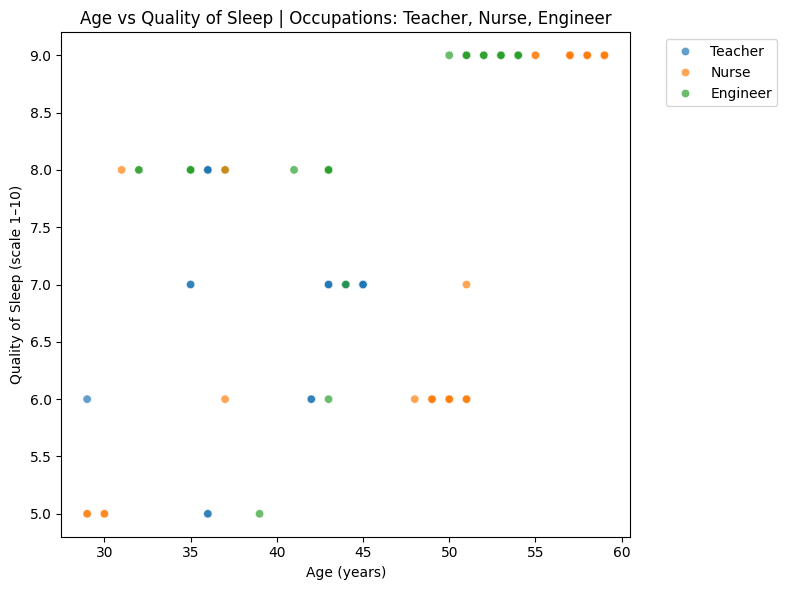

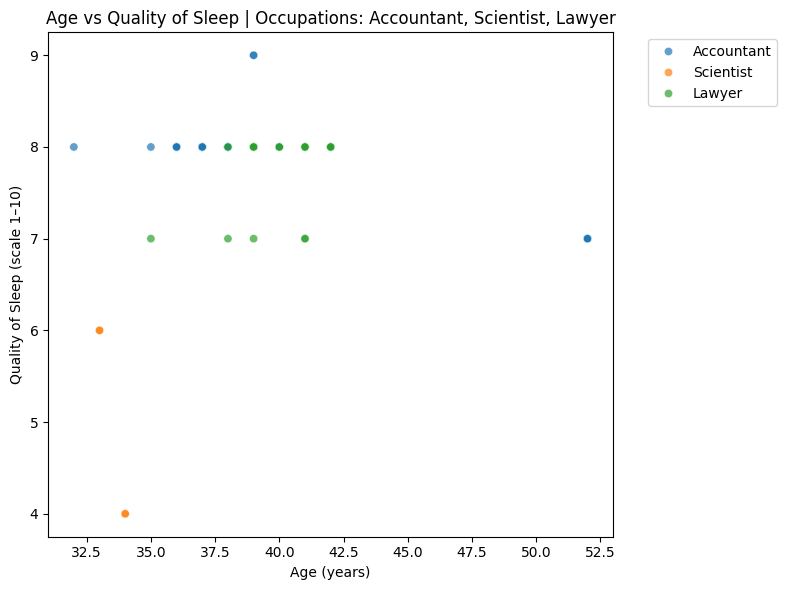

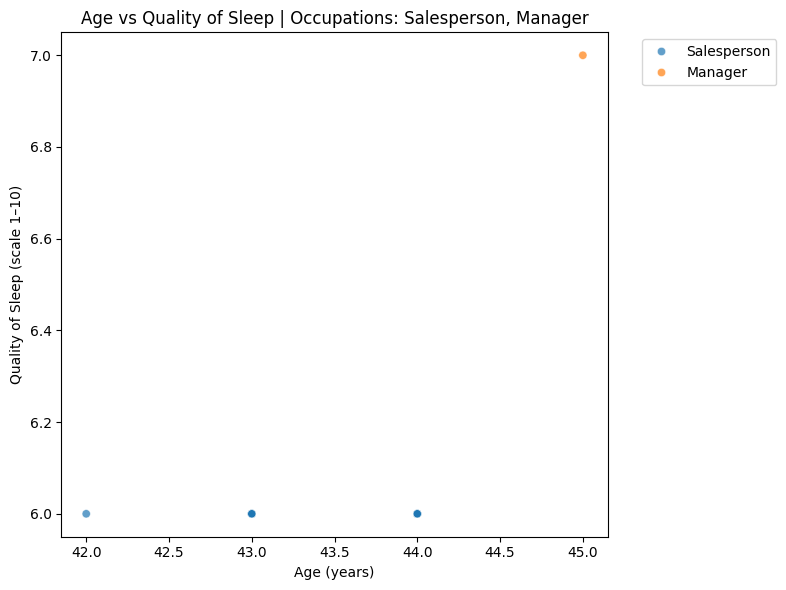

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Load and clean
df_sleep = pd.read_csv(file_path, encoding='ascii')

# Ensure numeric columns
numeric_cols = ['Age', 'Quality of Sleep']
for col in numeric_cols:
    df_sleep[col] = pd.to_numeric(df_sleep[col], errors='coerce')

# Drop missing values
plot_df = df_sleep.dropna(subset=['Age', 'Quality of Sleep', 'Occupation'])

# Compute Pearson correlation per occupation (optional analysis)
corrs = plot_df.groupby('Occupation').apply(lambda g: g['Age'].corr(g['Quality of Sleep']))
corr_df = corrs.reset_index()
corr_df.columns = ['Occupation', 'Age-Quality Correlation']
print(corr_df.head())
print("#####################################")

# Unique occupations
unique_occs = plot_df['Occupation'].unique()
n_occs = len(unique_occs)
group_size = 3

# Loop over chunks of 3 occupations
for i in range(0, n_occs, group_size):
    occ_group = unique_occs[i:i+group_size]
    subset = plot_df[plot_df['Occupation'].isin(occ_group)]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=subset, x='Age', y='Quality of Sleep', hue='Occupation', alpha=0.7)
    plt.title(f'Age vs Quality of Sleep | Occupations: {", ".join(occ_group)}')
    plt.xlabel('Age (years)')
    plt.ylabel('Quality of Sleep (scale 1–10)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# observation:

Key take-aways  
- Doctors and Engineers show a clear positive correlation: as age rises, their reported sleep quality tends to improve (roughly 0.64 and 0.71).  
- Accountants display a strong negative correlation (-0.81) — older accountants in this sample tend to report poorer sleep quality.  
- Lawyers show only a weak relationship (0.13), and Managers have too few valid records to quantify reliably (NaN).  
- The scatterplot confirms these directions but also reveals considerable spread within each group, so the correlations should be interpreted as tendencies, not absolutes.

In short, age appears to matter for sleep quality, but its effect is occupation-specific: positive for medical and engineering roles, negative for accounting, and negligible for law in this dataset.

          Lifestyle Factor  Correlation with Sleep Quality
0           Sleep Duration                        0.883213
1  Physical Activity Level                        0.192896
2              Daily Steps                        0.016791
3               Heart Rate                       -0.659865
4             Stress Level                       -0.898752
####################################


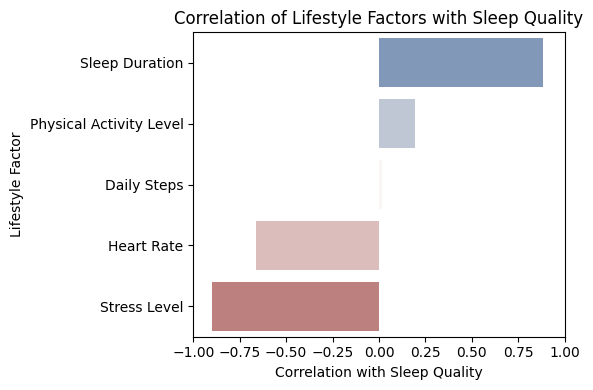

*****************************************


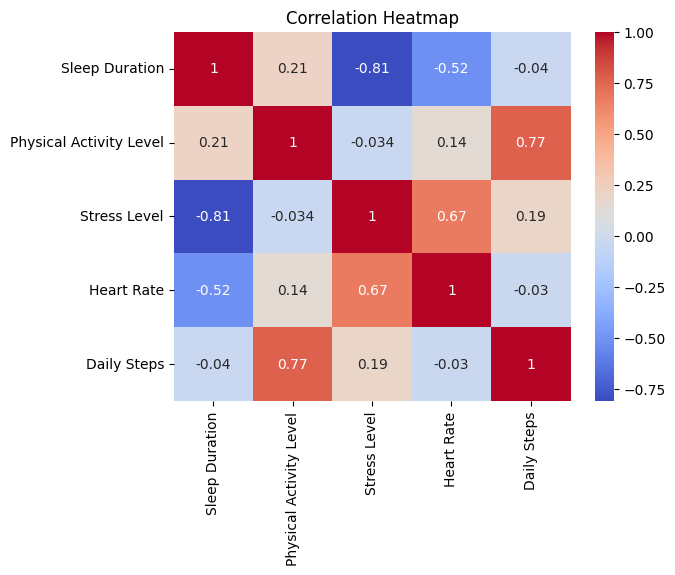

In [55]:
# Analyze the impact of lifestyle factors on sleep quality ? 

# Load and clean
df_sleep = pd.read_csv(file_path, encoding='ascii')

# Numeric lifestyle variables
num_vars = ['Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']

# Ensure numeric
for col in num_vars + ['Quality of Sleep']:
    df_sleep[col] = pd.to_numeric(df_sleep[col], errors='coerce')

# Correlation matrix for numeric lifestyle factors with Quality of Sleep
corrs = df_sleep[num_vars + ['Quality of Sleep']].corr()['Quality of Sleep'].drop('Quality of Sleep').sort_values(ascending=False)

# Display correlations table
corr_table = corrs.reset_index()
corr_table.columns = ['Lifestyle Factor', 'Correlation with Sleep Quality']
print(corr_table.head())
print("####################################")

# Plot correlations as bar
plt.figure(figsize=(6,4))
sns.barplot(
    x='Correlation with Sleep Quality',
    y='Lifestyle Factor',
    hue='Lifestyle Factor',
    data=corr_table,
    palette='vlag',
    legend=False
)


plt.title('Correlation of Lifestyle Factors with Sleep Quality')
plt.xlim(-1,1)
plt.tight_layout()
plt.show()
print("*****************************************")


# Correlation matrix: The numbers vary from -1 to +1.
# -1: stronly negtaive correlation
# +1: stronly positive correlation
# Numeric lifestyle variables

num_vars = ['Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']

corr = df_sleep[num_vars].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


    BMI Category  Quality of Sleep
0         Normal          7.661538
1  Normal Weight          7.428571
2          Obese          6.400000
3     Overweight          6.898649
++++++++++++++++++++++++++++++++++++++++++


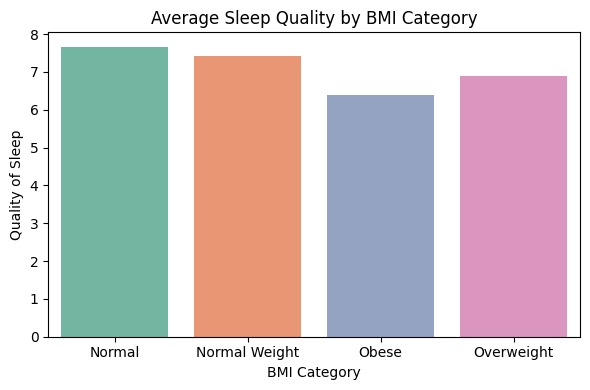

|||||||||||||||||||||||||||||||||||


In [56]:
# Load and clean
df_sleep = pd.read_csv(file_path, encoding='ascii')


# Categorical BMI Category average sleep quality
bmi_mean = df_sleep.groupby('BMI Category')['Quality of Sleep'].mean().reset_index()
print(bmi_mean.head())
print("++++++++++++++++++++++++++++++++++++++++++")

plt.figure(figsize=(6,4))
sns.barplot(
    x='BMI Category',
    y='Quality of Sleep',
    hue='BMI Category',
    data=bmi_mean,
    palette='Set2',
    legend=False
)


plt.title('Average Sleep Quality by BMI Category')
plt.tight_layout()
plt.show()
print("|||||||||||||||||||||||||||||||||||")

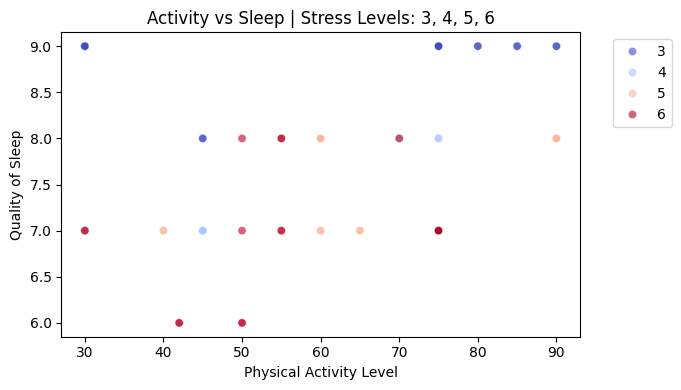

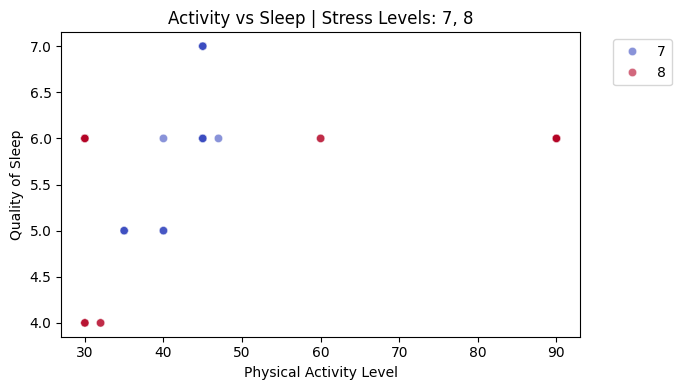

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Drop rows with missing values
plot_df = df_sleep.dropna(subset=['Physical Activity Level', 'Quality of Sleep', 'Stress Level'])

# Unique stress levels (assumed to be integers 0–10)
unique_stress_levels = sorted(plot_df['Stress Level'].unique())  # Optional: sort them
group_size = 4

# Loop over groups of 4 stress levels
for i in range(0, len(unique_stress_levels), group_size):
    stress_group = unique_stress_levels[i:i+group_size]
    subset = plot_df[plot_df['Stress Level'].isin(stress_group)]

    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=subset,
        x='Physical Activity Level',
        y='Quality of Sleep',
        hue='Stress Level',
        palette='coolwarm',
        alpha=0.6
    )
    # Convert stress levels to string for join
    plt.title(f'Activity vs Sleep | Stress Levels: {", ".join(map(str, stress_group))}')
    plt.tight_layout()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


# observation1
The strongest lifestyle drivers of sleep quality in this sample are easy to spot:
- Sleep Duration has a very strong positive link (0.88). Longer sleepers almost always rate their nights better.
- Stress Level shows the opposite pattern (−0.90). Higher perceived stress drags quality down sharply.
- Heart Rate is moderately negative (−0.66). People with lower resting heart-rates—often a sign of better cardiovascular fitness—sleep better.
- Physical Activity Level is mildly positive, while raw Daily Steps barely matters once activity intensity is accounted for.

# observation2
BMI adds another dimension: participants in the Normal range average the highest sleep-quality scores, with a gentle drop-off through Overweight to Obese.

# observation3
Scatterplot reveals how Physical Activity and Stress interact: at any given activity level, dots shaded cooler (low stress) cluster higher on the quality axis, while hotter (high-stress) dots sit lower. In other words, moving more only helps if stress is kept in check.


## Putting it all together

- Prioritise sufficient sleep hours—nothing else rivals its effect size here.
- Manage stress aggressively; its impact can wipe out the gains from exercise.
- Aim for a healthy BMI and cardiovascular fitness (lower resting heart rate) to further boost sleep quality.